# Horse Gait Classifier — Training Notebook

Trains a 1D CNN to classify horse gaits (walk, trot, canter) from phone
accelerometer data recorded by the InterEqui app.

**Outputs:**
- `gait_classifier.tflite` — quantised model for on-device inference
- `norm_params.json` — per-axis mean/std needed to normalise input on the phone

Upload one or more `.csv.gz` files exported from the app, then run all cells.

In [15]:
# --- Cell 1: Install dependencies ---
%pip install -q tensorflow pandas scikit-learn matplotlib ai-edge-litert

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# --- Cell 2: Load data files ---
# Set DATA_DIR to the folder containing your .csv.gz files.
# In Colab: upload files first; locally: just point to the right path.
import os, glob

DATA_DIR = r"G:\My Drive\Training"  # <-- change if your files are elsewhere

try:
    from google.colab import files as colab_files
    print("Running in Colab — upload your .csv.gz files:")
    uploaded = colab_files.upload()
    DATA_FILES = sorted(uploaded.keys())
except ImportError:
    # Local Jupyter / VS Code — scan DATA_DIR for .csv.gz files
    DATA_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv.gz")))
    if not DATA_FILES:
        raise FileNotFoundError(
            f"No .csv.gz files found in '{os.path.abspath(DATA_DIR)}'.\n"
            "Set DATA_DIR to the folder containing your exported files."
        )

print(f"\nFound {len(DATA_FILES)} file(s):")
for f in DATA_FILES:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f)}  ({size_kb:.0f} KB)")


Found 4 file(s):
  gait_data_2026-03-03T18-29-23-602782.csv.gz  (2676 KB)
  gait_data_2026-03-04T18-13-55-888027.csv.gz  (2820 KB)
  gait_data_2026-03-05T09-06-53-484097.csv.gz  (2738 KB)
  gait_data_2026-03-05T18-12-39-028383.csv.gz  (2149 KB)


In [17]:
# --- Cell 3: Load & inspect data ---
import pandas as pd
import numpy as np

LABEL_MAP = {"walk": 0, "trot": 1, "canter": 2}
LABELS = list(LABEL_MAP.keys())

dfs = []
for f in DATA_FILES:
    df = pd.read_csv(f)  # pandas reads .csv.gz transparently
    df["source"] = f
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Drop rows whose label isn't one of our known gaits
data = data[data["label"].isin(LABEL_MAP)].copy()
data["label_enc"] = data["label"].map(LABEL_MAP)

print(f"Total samples: {len(data):,}")
print(f"Duration:      ~{len(data) / 100 / 60:.1f} min (at 100 Hz)")
print(f"\nClass distribution:")
print(data["label"].value_counts())
print(f"\nAccelerometer stats:")
data[["accel_x", "accel_y", "accel_z"]].describe().round(3)

Total samples: 851,818
Duration:      ~142.0 min (at 100 Hz)

Class distribution:
label
walk    653127
trot    198691
Name: count, dtype: int64

Accelerometer stats:


,accel_x,accel_y,accel_z
count,851818.000,851818.000,851818.000
mean,-4.323,-4.348,-6.575
std,3.417,4.104,3.236
min,-27.915,-60.701,-28.989
25%,-6.374,-6.597,-7.841
50%,-4.649,-4.405,-6.946
75%,-2.422,-1.845,-5.922
max,18.028,33.239,32.995


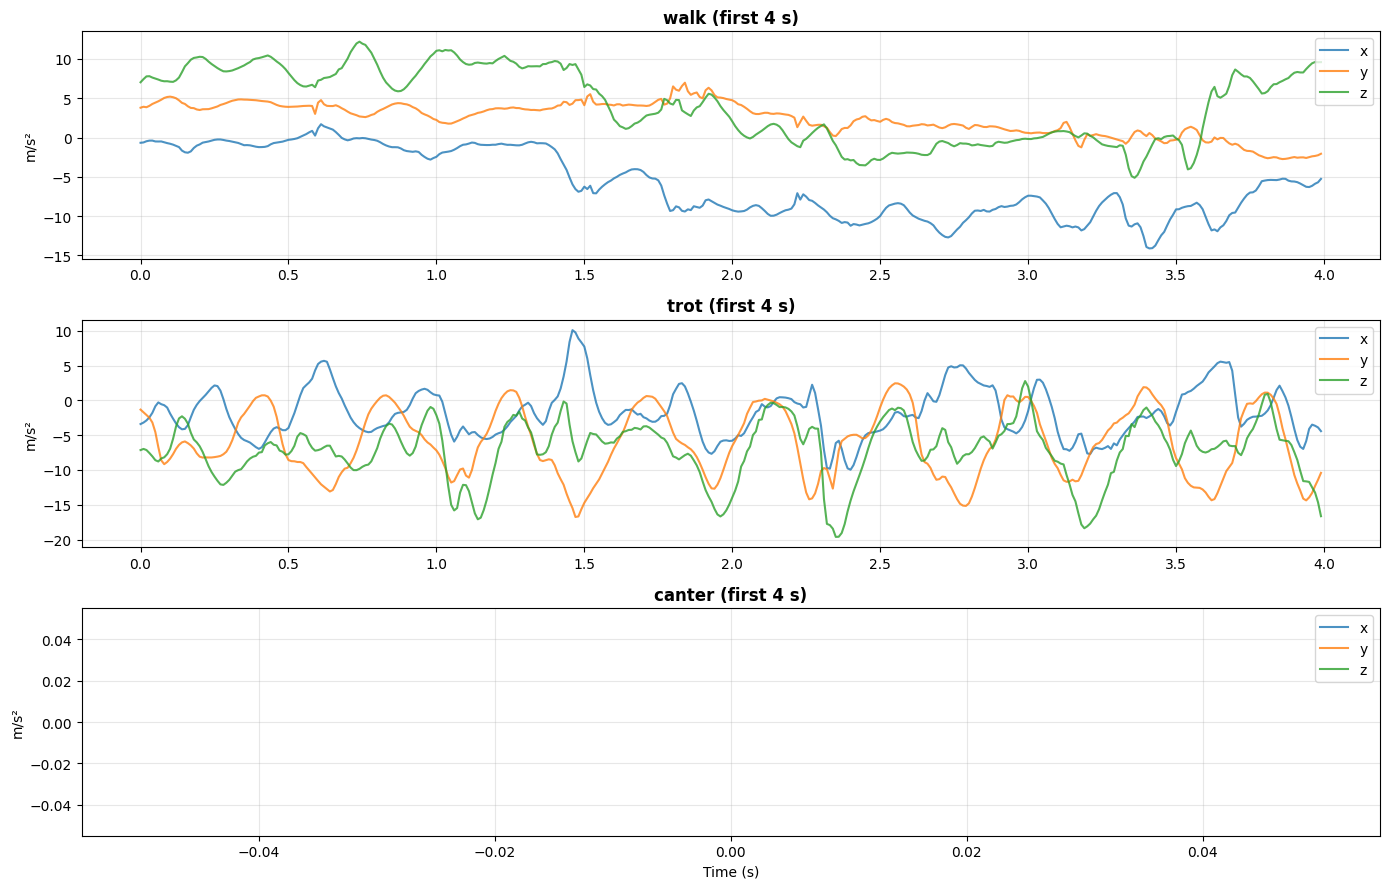

In [18]:
# --- Cell 4: Visualise a sample of each gait ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(LABELS), 1, figsize=(14, 3 * len(LABELS)), sharex=False)

for ax, label in zip(axes, LABELS):
    subset = data[data["label"] == label].iloc[:400]  # 4 seconds
    t = np.arange(len(subset)) / 100.0  # seconds
    ax.plot(t, subset["accel_x"], label="x", alpha=0.8)
    ax.plot(t, subset["accel_y"], label="y", alpha=0.8)
    ax.plot(t, subset["accel_z"], label="z", alpha=0.8)
    ax.set_title(f"{label} (first 4 s)", fontweight="bold")
    ax.set_ylabel("m/s\u00b2")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [20]:
# --- Cell 5: Normalise & compute magnitude channel ---
import json

ACCEL_COLS = ["accel_x", "accel_y", "accel_z"]

means = data[ACCEL_COLS].mean().values
stds  = data[ACCEL_COLS].std().values

# Save for on-device inference
norm_params = {"means": means.tolist(), "stds": stds.tolist()}
with open("norm_params.json", "w") as f:
    json.dump(norm_params, f, indent=2)
print("Saved norm_params.json")
print(f"  means: {means.round(4)}")
print(f"  stds:  {stds.round(4)}")

# Z-score normalise
data[ACCEL_COLS] = (data[ACCEL_COLS] - means) / stds

# Add magnitude as 4th channel (orientation-invariant)
data["accel_mag"] = np.sqrt(
    data["accel_x"] ** 2 + data["accel_y"] ** 2 + data["accel_z"] ** 2
)

FEATURE_COLS = ACCEL_COLS + ["accel_mag"]
N_CHANNELS = len(FEATURE_COLS)
print(f"Using {N_CHANNELS} channels: {FEATURE_COLS}")

Saved norm_params.json
  means: [-0.  0. -0.]
  stds:  [1. 1. 1.]
Using 4 channels: ['accel_x', 'accel_y', 'accel_z', 'accel_mag']


In [21]:
# --- Cell 6: Sliding window segmentation ---

WINDOW_SIZE = 200   # 2 seconds at 100 Hz
STRIDE      = 100   # 50% overlap -> 1 classification per second

def create_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    """Slice a contiguous DataFrame into (X, y) windows."""
    values = df[FEATURE_COLS].values.astype(np.float32)
    labels = df["label_enc"].values.astype(np.int32)
    X, y = [], []
    for start in range(0, len(values) - window_size, stride):
        end = start + window_size
        window_labels = labels[start:end]
        # Skip windows that span a gait transition
        if len(np.unique(window_labels)) > 1:
            continue
        X.append(values[start:end])
        y.append(window_labels[0])
    return np.array(X), np.array(y)

# Window each recording session separately to avoid crossing session gaps
all_X, all_y, session_ids = [], [], []
for i, (source, group) in enumerate(data.groupby("source")):
    Xi, yi = create_windows(group)
    all_X.append(Xi)
    all_y.append(yi)
    session_ids.extend([i] * len(yi))
    print(f"  {source}: {len(yi)} windows")

X = np.concatenate(all_X)
y = np.concatenate(all_y)
session_ids = np.array(session_ids)

print(f"\nTotal windows: {len(X)}")
print(f"Shape: {X.shape}  (windows, timesteps, channels)")
for label, name in enumerate(LABELS):
    print(f"  {name}: {np.sum(y == label)}")

  G:\My Drive\Training\gait_data_2026-03-03T18-29-23-602782.csv.gz: 2142 windows
  G:\My Drive\Training\gait_data_2026-03-04T18-13-55-888027.csv.gz: 2311 windows
  G:\My Drive\Training\gait_data_2026-03-05T09-06-53-484097.csv.gz: 2243 windows
  G:\My Drive\Training\gait_data_2026-03-05T18-12-39-028383.csv.gz: 1759 windows

Total windows: 8455
Shape: (8455, 200, 4)  (windows, timesteps, channels)
  walk: 6497
  trot: 1958
  canter: 0


In [22]:
# --- Cell 7: Train / validation split ---
# If we have multiple sessions, split by session to avoid data leakage.
# Otherwise fall back to a stratified random split.

from sklearn.model_selection import train_test_split, GroupShuffleSplit

n_sessions = len(np.unique(session_ids))

if n_sessions >= 3:
    # Group split: entire sessions go to train or val
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(gss.split(X, y, groups=session_ids))
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    print(f"Group split by session ({n_sessions} sessions)")
else:
    # Too few sessions for group split; use stratified random
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    print(f"Stratified random split (only {n_sessions} session(s))")

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")
for label, name in enumerate(LABELS):
    print(f"  {name}:  train={np.sum(y_train==label)}  val={np.sum(y_val==label)}")

Group split by session (4 sessions)
Train: 6144  |  Val: 2311
  walk:  train=4726  val=1771
  trot:  train=1418  val=540
  canter:  train=0  val=0


In [24]:
# --- Cell 8: Build 1D CNN ---
import tensorflow as tf
from tensorflow import keras
from keras import layers

def build_model(window_size=WINDOW_SIZE, n_channels=N_CHANNELS, n_classes=len(LABELS)):
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_channels)),

        # Block 1: short patterns (individual footfalls)
        layers.Conv1D(64, kernel_size=5, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),        # -> (100, 64)

        # Block 2: stride-level patterns
        layers.Conv1D(128, kernel_size=5, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),        # -> (50, 128)

        # Block 3: gait-level patterns
        layers.Conv1D(128, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling1D(),         # -> (128,)

        # Classifier head
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 200, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,443 (396.26 KB)

 Trainable params: 100,803 (393.76 KB)

 Non-trainable params: 640 (2.50 KB)

In [25]:
# --- Cell 9: Handle class imbalance & train ---
from sklearn.utils.class_weight import compute_class_weight

# Only compute weights for classes that actually appear in the data
present_classes = np.unique(y_train)
missing = [LABELS[i] for i in range(len(LABELS)) if i not in present_classes]
if missing:
    print(f"NOTE: no training samples for: {missing}")
    print(f"      the model will only learn to distinguish: "
          f"{[LABELS[i] for i in present_classes]}")
    print(f"      record more sessions to cover all gaits.\n")

class_weights = compute_class_weight(
    class_weight="balanced", classes=present_classes, y=y_train
)
class_weight_dict = {int(c): w for c, w in zip(present_classes, class_weights)}
print(f"Class weights: {class_weight_dict}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=12, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, verbose=1
        ),
    ],
)

NOTE: no training samples for: ['canter']
      the model will only learn to distinguish: ['walk', 'trot']
      record more sessions to cover all gaits.

Class weights: {0: np.float64(0.6500211595429539), 1: np.float64(2.1664315937940763)}
Epoch 1/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9801 - loss: 0.0735 - val_accuracy: 0.9740 - val_loss: 0.1291 - learning_rate: 0.0010
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9873 - loss: 0.0481 - val_accuracy: 0.9701 - val_loss: 0.0984 - learning_rate: 0.0010
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9893 - loss: 0.0493 - val_accuracy: 0.9701 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9899 - loss: 0.0394 - val_accuracy: 0.9749 - val_loss: 0.0946 - learning_rate: 0.0010
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9899 - loss: 0.0395 - val_accuracy: 0.9745 - val_loss: 0.0884 - learning_rate: 0

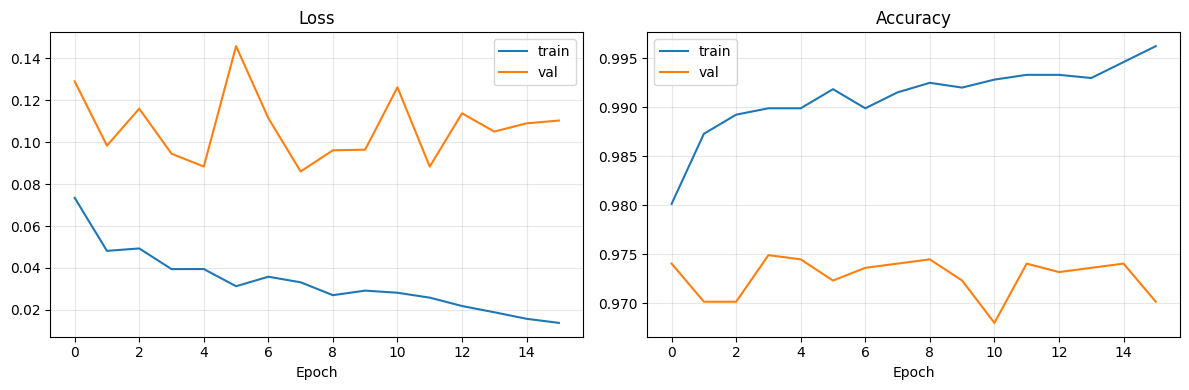

In [26]:
# --- Cell 10: Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

        walk       0.97      1.00      0.98      1771
        trot       0.99      0.90      0.94       540

    accuracy                           0.97      2311
   macro avg       0.98      0.95      0.96      2311
weighted avg       0.98      0.97      0.97      2311



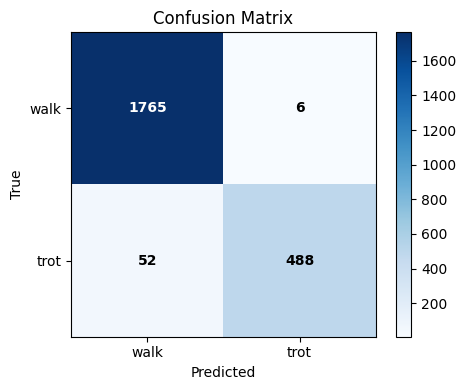

In [27]:
# --- Cell 11: Confusion matrix ---
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_val).argmax(axis=1)

# Use only the classes that actually appear in the data
present_classes = sorted(set(np.unique(y_val)) | set(np.unique(y_pred)))
present_names = [LABELS[i] for i in present_classes]

print(classification_report(y_val, y_pred, labels=present_classes, target_names=present_names))

cm = confusion_matrix(y_val, y_pred, labels=present_classes)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(present_names)))
ax.set_yticks(range(len(present_names)))
ax.set_xticklabels(present_names)
ax.set_yticklabels(present_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
for i in range(len(present_names)):
    for j in range(len(present_names)):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontweight="bold")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [28]:
# --- Cell 12: Convert to TFLite (float16 quantisation) ---

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

TFLITE_PATH = "gait_classifier.tflite"
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"Saved {TFLITE_PATH}  ({size_kb:.0f} KB)")

INFO:tensorflow:Assets written to: C:\Users\SEBAST~1\AppData\Local\Temp\tmpserfjwhr\assets


INFO:tensorflow:Assets written to: C:\Users\SEBAST~1\AppData\Local\Temp\tmpserfjwhr\assets


Saved artifact at 'C:\Users\SEBAST~1\AppData\Local\Temp\tmpserfjwhr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 4), dtype=tf.float32, name='keras_tensor_34')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2146647453584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647453008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647453968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647454928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647454736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647454160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647454544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647453776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647453392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146647456080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2146

In [29]:
# --- Cell 13: Verify TFLite model matches Keras predictions ---
try:
    from ai_edge_litert import interpreter as litert
    interpreter = litert.Interpreter(model_path=TFLITE_PATH)
except ImportError:
    interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)

interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input:  {input_details[0]['shape']}  dtype={input_details[0]['dtype']}")
print(f"Output: {output_details[0]['shape']} dtype={output_details[0]['dtype']}")

# Compare predictions on a few validation samples
n_check = min(50, len(X_val))
tflite_preds = []
for i in range(n_check):
    sample = X_val[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds.append(out[0].argmax())

keras_preds = model.predict(X_val[:n_check]).argmax(axis=1)
match_rate = np.mean(np.array(tflite_preds) == keras_preds)
print(f"\nTFLite vs Keras agreement: {match_rate:.1%}  ({n_check} samples)")
if match_rate < 0.95:
    print("WARNING: significant divergence — consider using float32 instead of float16")

Input:  [  1 200   4]  dtype=<class 'numpy.float32'>
Output: [1 3] dtype=<class 'numpy.float32'>
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

TFLite vs Keras agreement: 100.0%  (50 samples)


In [30]:
# --- Cell 14: Download / locate outputs ---

print("Output files ready:")
print(f"  gait_classifier.tflite  ({size_kb:.0f} KB)")
print(f"  norm_params.json")
print()
print("Place both files in your Flutter project:")
print("  assets/models/gait_classifier.tflite")
print("  assets/models/norm_params.json")

try:
    from google.colab import files as colab_files
    colab_files.download("gait_classifier.tflite")
    colab_files.download("norm_params.json")
except ImportError:
    # Running locally — files are already in the working directory
    print(f"\nFiles saved to: {os.path.abspath('.')}")

Output files ready:
  gait_classifier.tflite  (204 KB)
  norm_params.json

Place both files in your Flutter project:
  assets/models/gait_classifier.tflite
  assets/models/norm_params.json

Files saved to: c:\Users\Sebastien\Documents\Repos\InterEqui\notebooks
